In [1]:
import os

os.environ["GTIFF_SRS_SOURCE"] = "EPSG"
os.environ["PROJ_LIB"] = ""

In [2]:
!pip install terratorch
!pip install gdown tensorboard
!pip install -U jupyter ipywidgets

In [3]:
import os
import sys
import torch
import gdown
import terratorch
import albumentations
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
import warnings

warnings.filterwarnings("ignore")

W0423 14:45:22.395000 15264 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [8]:
from huggingface_hub import snapshot_download

DATASET_PATH = "./SmallMinesDS"

snapshot_download(
    repo_id="ellaampy/SmallMinesDS",
    repo_type="dataset",
    local_dir=DATASET_PATH,
    local_dir_use_symlinks=False
)

print("Dataset en:", DATASET_PATH)

Dataset en: ./SmallMinesDS


In [ ]:
import zipfile

with zipfile.ZipFile("SmallMinesDS/SmallMinesDS.zip", 'r') as z:
    z.extractall("SmallMinesDS")

In [9]:
!dir SmallMinesDS\SmallMinesDS

 Volume in drive C is Windows-SSD
 Volume Serial Number is 789D-9F40

 Directory of C:\Users\plieg\PycharmProjects\Minery\SmallMinesDS\SmallMinesDS

03/04/2026  20:08    <DIR>          .
03/04/2026  20:08    <DIR>          ..
03/04/2026  20:08    <DIR>          2016
03/04/2026  20:08    <DIR>          2022
               0 File(s)              0 bytes
               4 Dir(s)  109,106,569,216 bytes free


In [10]:
import rasterio

path = "SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_1211_2022.tif"

with rasterio.open(path) as src:
    print("bands or mask:", src.count)
    print("shape of mask:", (src.count, src.height, src.width))

path = "SmallMinesDS/SmallMinesDS/2022/IMAGE/IMG_GH_1211_2022.tif"

with rasterio.open(path) as src:
    print("bands of image:", src.count)
    print("shape of image:", (src.count, src.height, src.width))

2026-04-23 14:46:08,958 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:46:09,020 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db


bands or mask: 1
shape of mask: (1, 128, 128)
bands of image: 13
shape of image: (13, 128, 128)


In [11]:
OUT_DIR = "./mine_example"

# ==================================================
# TRAINING
# ==================================================

BATCH_SIZE = 8
# RTX 4060 + Prithvi temporal + 26-channel multitemporal input
# batch_size=16 probablemente dará OOM
# empezar con 8 es mucho más realista

EPOCHS = 50

LR = 2e-4

WEIGHT_DECAY = 0.05
# 0.1 suele ser demasiado agresivo para fine-tuning de foundation models

HEAD_DROPOUT = 0.1

FREEZE_BACKBONE = False
# queremos fine-tuning real del backbone temporal

SEED = 0


# ==================================================
# MULTITEMPORAL CONFIG
# ==================================================

NUM_FRAMES = 2
# t1 = 2016
# t2 = 2022

# SmallMinesDS:
# 13 bandas por timestamp
#
# 0-9   -> Sentinel-2
# 10-11 -> Sentinel-1
# 12    -> DEM

BANDS = [
    # -------------------------
    # Sentinel-2
    # -------------------------
    "BLUE",         # index 0
    "GREEN",        # index 1
    "RED",          # index 2
    "RED_EDGE_1",   # index 3
    "RED_EDGE_2",   # index 4
    "RED_EDGE_3",   # index 5
    "NIR",          # index 6
    "RED_EDGE_4",   # index 7 (B8A / narrow NIR)
    "SWIR_1",       # index 8
    "SWIR_2",       # index 9

    # -------------------------
    # Sentinel-1
    # -------------------------
    "VV",           # index 10
    "VH",           # index 11

    # -------------------------
    # Copernicus DEM
    # -------------------------
    "DEM"           # index 12
]

NUM_INPUT_CHANNELS = len(BANDS)   # 13


# IMPORTANTE:
#
# Terratorch temporal backbone espera:
#
# (B, C, T, H, W)
#
# donde:
#
# C = 13
# T = 2
#
# Entonces:
#
# input raster stackeado original:
#
# (26, 128, 128)
#
# porque:
#
# 13 bandas × 2 timestamps = 26 canales
#
# luego con:
#
# expand_temporal_dimension=True
#
# Terratorch convierte:
#
# (26, H, W)
# ->
# (13, 2, H, W)


# ==================================================
# SEGMENTATION CONFIG
# ==================================================

NUM_CLASSES = 2

# clases reales verificadas:
#
# 0 -> background
# 1 -> mine

CLASS_WEIGHTS = [
    0.2,   # background
    0.8    # mine
]

# IMPORTANTE:
#
# tus máscaras verificaron:
#
# np.unique(mask) = [0, 1]
#
# por tanto:
#
# esto es segmentación binaria real
#
# NO multiclass
# NO 13 class weights

IGNORE_INDEX = None
# no se observa clase ignore en SmallMinesDS


# ==================================================
# DATASET
# ==================================================

PATCH_SIZE = 128

IMAGE_SHAPE_PER_TIMESTAMP = (13, 128, 128)

STACKED_IMAGE_SHAPE = (26, 128, 128)
# 2016 + 2022

TEMPORAL_IMAGE_SHAPE = (13, 2, 128, 128)
# después de expand_temporal_dimension=True

MASK_SHAPE = (1, 128, 128)

MASK_VALUES = [0, 1]


# ==================================================
# DATA SPLIT STRATEGY
# ==================================================

# usar:
#
# train_test_splits_2022.csv
#
# porque:
#
# target = MASK_2022
#
# NO usar:
#
# train_test_splits_2016.csv
#
# 2016 se usa solo como contexto temporal


TARGET_YEAR = 2022
CONTEXT_YEAR = 2016

In [16]:
import albumentations as A
from albumentations.pytorch import ToTensorV2


train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    ToTensorV2(),
])

In [18]:
# =========================================================
# IMPORTS
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import rasterio

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset, DataLoader


# =========================================================
# CONFIG
# =========================================================

DATASET_PATH = "SmallMinesDS"

# =========================================================
# TRANSFORMS
# =========================================================

# IMPORTANTE:
#
# NO usar:
#
# FlattenTemporalIntoChannels()
# UnflattenTemporalFromChannels()
#
# aquí NO
#
# porque tu Dataset YA devuelve:
#
# image.shape = (26, H, W)
#
# ya está stackeado:
#
# 2016 (13)
# +
# 2022 (13)
#
# = 26 canales


train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    ToTensorV2(),
])

val_transforms = A.Compose([
    ToTensorV2(),
])


# =========================================================
# DATASET
# =========================================================

class SmallMinesMultiTemporalDataset(Dataset):
    """
    Problema:

        (IMG_2016, IMG_2022) -> MASK_2022

    usando:

        train_test_splits_2022.csv

    como split principal.

    ------------------------------------------------

    INPUT:
        image -> (26, H, W)

    TARGET:
        mask -> (H, W)

    clases:
        0 -> background
        1 -> mine
    """

    def __init__(
        self,
        root_dir,
        split="train",
        transform=None,
        check_alignment=False,
    ):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.check_alignment = check_alignment

        # --------------------------------------------
        # CSV principal
        # --------------------------------------------

        csv_path = os.path.join(
            root_dir,
            "data_splits",
            "train_test_splits_2022.csv"
        )

        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"No existe:\n{csv_path}"
            )

        self.df = pd.read_csv(csv_path)

        print("Splits disponibles:")
        print(self.df["split"].unique())

        self.df = self.df[
            self.df["split"] == split
        ].reset_index(drop=True)

        if len(self.df) == 0:
            raise ValueError(
                f"No hay muestras para split='{split}'"
            )

        # --------------------------------------------
        # Directorios base
        # --------------------------------------------

        self.img_2016_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2016",
            "IMAGE"
        )

        self.img_2022_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2022",
            "IMAGE"
        )

        self.mask_2022_dir = os.path.join(
            root_dir,
            "SmallMinesDS",
            "2022",
            "MASK"
        )

        print("\n==============================")
        print("SmallMinesMultiTemporalDataset")
        print("==============================")
        print(f"Split   : {split}")
        print(f"Samples : {len(self.df)}")
        print("==============================\n")

    def __len__(self):
        return len(self.df)

    # =====================================================
    # HELPERS
    # =====================================================

    def _extract_patch_id(self, filename):
        """
        Ejemplo:

            MASK_GH_0150_2022.tif
            -> 0150
        """

        match = re.search(r"_(\d{4})_", filename)

        if match is None:
            raise ValueError(
                f"No se pudo extraer patch_id de:\n{filename}"
            )

        return match.group(1)

    def _build_paths(self, patch_id):
        img_2016 = os.path.join(
            self.img_2016_dir,
            f"IMG_GH_{patch_id}_2016.tif"
        )

        img_2022 = os.path.join(
            self.img_2022_dir,
            f"IMG_GH_{patch_id}_2022.tif"
        )

        mask_2022 = os.path.join(
            self.mask_2022_dir,
            f"MASK_GH_{patch_id}_2022.tif"
        )

        return img_2016, img_2022, mask_2022

    def _read_image(self, path):
        with rasterio.open(path) as src:
            image = src.read()

        return image.astype(np.float32)

    def _read_mask(self, path):
        with rasterio.open(path) as src:
            mask = src.read(1)

        mask = (mask > 0).astype(np.uint8)

        return mask

    # =====================================================
    # MAIN
    # =====================================================

    def __getitem__(self, idx):
        print(f"\nLoading sample idx = {idx}")

        row = self.df.iloc[idx]

        print("reading CSV row...")

        mask_name = row["patch_name"]

        patch_id = self._extract_patch_id(mask_name)

        print("building paths...")

        img_2016_path, img_2022_path, mask_2022_path = \
            self._build_paths(patch_id)

        print("checking files...")

        for path in [
            img_2016_path,
            img_2022_path,
            mask_2022_path
        ]:
            if not os.path.exists(path):
                raise FileNotFoundError(
                    f"No existe archivo:\n{path}"
                )

        print("reading images...")

        img_2016 = self._read_image(img_2016_path)
        img_2022 = self._read_image(img_2022_path)
        mask_2022 = self._read_mask(mask_2022_path)

        print("stacking temporal image...")

        image = np.stack(
            [img_2016, img_2022],
            axis=1
        )

        if self.transform is not None:
            print("applying transforms...")

            image_for_aug = image.reshape(
                13 * NUM_FRAMES,
                image.shape[2],
                image.shape[3]
            )

            transformed = self.transform(
                image=image_for_aug.transpose(1, 2, 0),
                mask=mask_2022
            )

            image = transformed["image"]
            mask_2022 = transformed["mask"]

            image = image.view(
                13,
                NUM_FRAMES,
                image.shape[1],
                image.shape[2]
            )

        print("final tensor conversion...")

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float()

        if not isinstance(mask_2022, torch.Tensor):
            mask_2022 = torch.from_numpy(mask_2022)

        mask_2022 = mask_2022.long()

        print("returning sample...")

        return {
            "image": image,
            "mask": mask_2022,
            "filename": row["patch_name"],
        }

In [19]:
import pandas as pd

df = pd.read_csv(
    "SmallMinesDS/data_splits/train_test_splits_2022.csv"
)

print(df["split"].unique())

<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str


In [20]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [21]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import os
import warnings

os.environ["GTIFF_SRS_SOURCE"] = "EPSG"

warnings.filterwarnings("ignore")

# =========================================================
# DATASETS
# =========================================================

train_dataset = SmallMinesMultiTemporalDataset(
    root_dir=DATASET_PATH,
    split="train",
    transform=train_transforms,
    check_alignment=False
)

val_dataset = SmallMinesMultiTemporalDataset(
    root_dir=DATASET_PATH,
    split="test",
    transform=val_transforms,
    check_alignment=False
)

# =========================================================
# DATALOADERS
# =========================================================

# SOLO para sanity check manual:
# mejor usar num_workers=0

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

# =========================================================
# SANITY CHECK
# =========================================================

print("\n==============================")
print("SINGLE SAMPLE CHECK")
print("==============================")

sample = train_dataset[0]

print("image shape:", sample["image"].shape)
print("mask shape :", sample["mask"].shape)
print("mask unique:", torch.unique(sample["mask"]))

print("==============================\n")

print("==============================")
print("LOADING FIRST BATCH...")
print("==============================")

for i, batch in enumerate(tqdm(train_loader, desc="Checking batches")):
    print(batch["image"].shape)

print("==============================")
print("BATCH CHECK")
print("==============================")

print("batch image shape:", batch["image"].shape)
print("batch mask shape :", batch["mask"].shape)

print("==============================")

2026-04-23 14:47:16,071 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:47:16,084 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:47:16,094 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db


Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : train
Samples : 1491

Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : test
Samples : 644


SINGLE SAMPLE CHECK

Loading sample idx = 0
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
image shape: torch.Size([13, 2, 128, 128])
mask shape : torch.Size([128, 128])
mask unique: tensor([0, 1])

LOADING FIRST BATCH...


Checking batches:   0%|          | 0/1491 [00:00<?, ?it/s]

2026-04-23 14:47:16,157 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:47:16,164 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:47:16,173 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 43
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


...

stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 704
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 212
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 1232
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 1443
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
retur

2026-04-23 14:48:10,138 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,155 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,171 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,184 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,195 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,210 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,221 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,232 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,245 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,256 - WA

stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 547
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 199
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 1312
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 410
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
return

2026-04-23 14:48:10,352 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,367 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,377 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,388 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,399 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,410 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,420 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,438 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,450 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:10,462 - WA

stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 938
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 394
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])

Loading sample idx = 1385
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...
torch.Size([1, 13, 2, 128, 128])
BATCH CHECK
batch image shape: torch.Size([1, 13, 2, 128, 128])
batch mask shape : torch.Size([1, 128, 128])


In [22]:
import lightning.pytorch as pl
from torch.utils.data import DataLoader


class SmallMinesDataModule(pl.LightningDataModule):
    """
    DataModule para:

        (IMG_2016, IMG_2022) -> MASK_2022

    usando:

        SmallMinesMultiTemporalDataset
    """

    def __init__(
        self,
        root_dir,
        batch_size=8,
        num_workers=0,
        train_transform=None,
        val_transform=None,
    ):
        super().__init__()

        self.root_dir = root_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_transform = train_transform
        self.val_transform = val_transform

    def prepare_data(self):
        """
        Aquí normalmente irían:
        - downloads
        - preprocessing global

        En tu caso no hace falta.
        """
        pass

    def setup(self, stage=None):
        """
        stage:
            fit
            validate
            test
            predict
        """

        # -----------------------------------
        # TRAIN + VALIDATION
        # -----------------------------------

        if stage in ["fit", "validate", None]:
            self.train_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="train",
                transform=self.train_transform,
                check_alignment=False,
            )

            # usamos split="test"
            # como validation temporal
            self.val_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="test",
                transform=self.val_transform,
                check_alignment=False,
            )

        # -----------------------------------
        # TEST
        # -----------------------------------

        if stage in ["test", None]:
            self.test_dataset = SmallMinesMultiTemporalDataset(
                root_dir=self.root_dir,
                split="test",
                transform=self.val_transform,
                check_alignment=False,
            )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False,
        )

2026-04-23 14:48:28,420 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,426 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,426 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 0
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


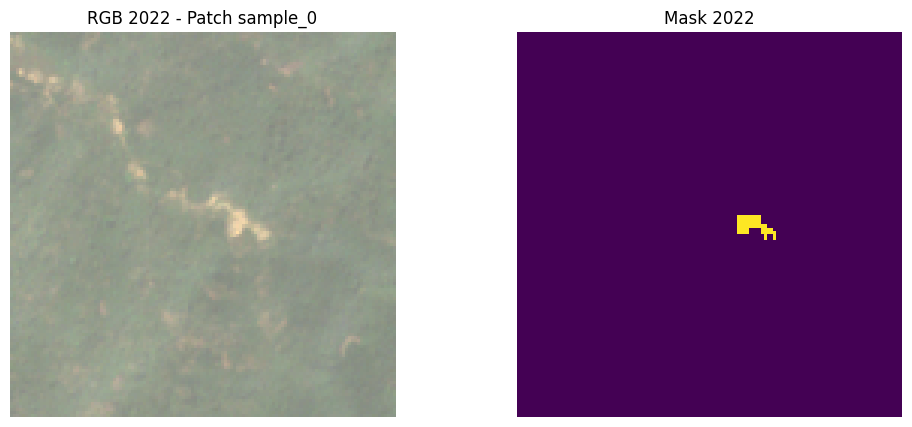

2026-04-23 14:48:28,633 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,665 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,666 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 1
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


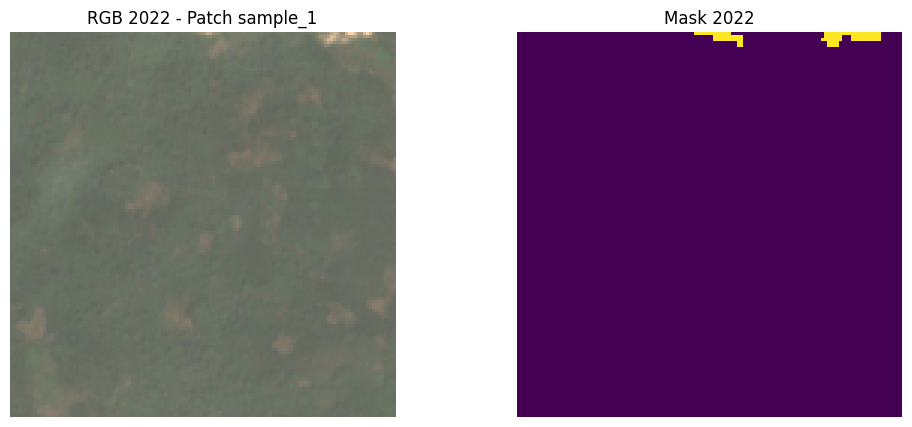

2026-04-23 14:48:28,739 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,739 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,753 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 2
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


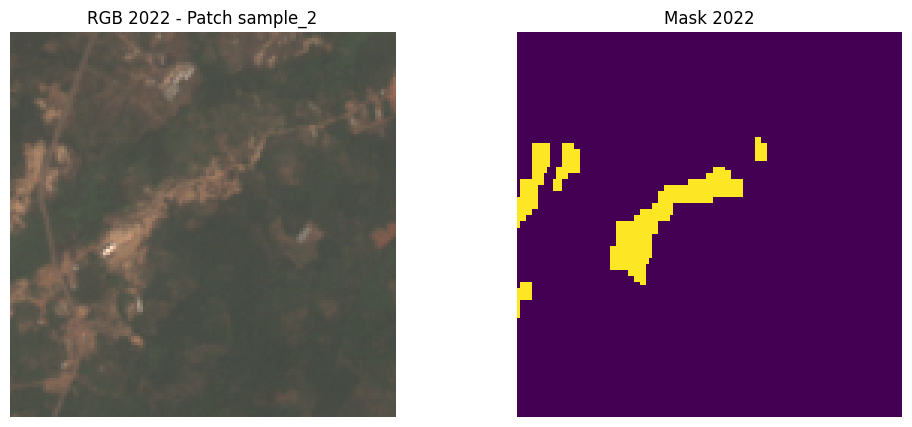

2026-04-23 14:48:28,816 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,820 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,829 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 3
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


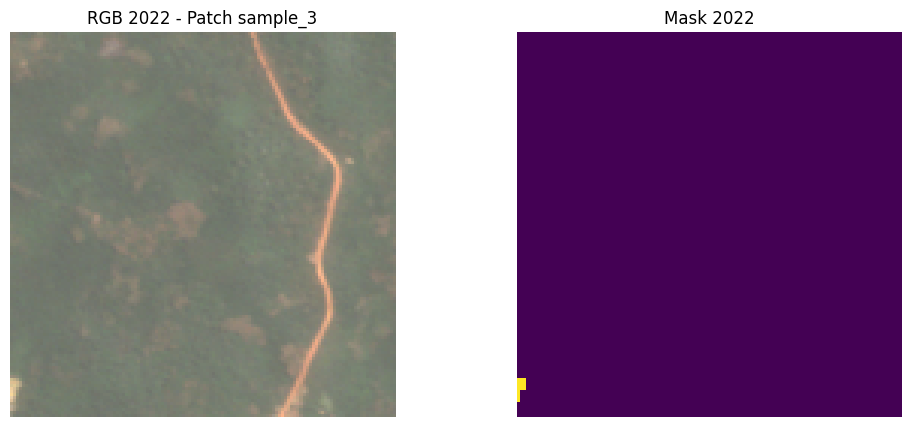

2026-04-23 14:48:28,896 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,902 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db
2026-04-23 14:48:28,909 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: Cannot find proj.db



Loading sample idx = 4
reading CSV row...
building paths...
checking files...
reading images...
stacking temporal image...
applying transforms...
final tensor conversion...
returning sample...


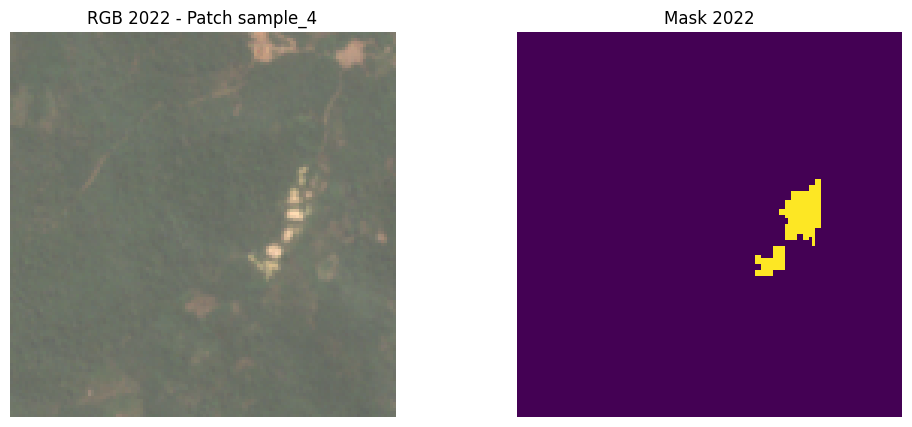

In [23]:
import matplotlib.pyplot as plt
import numpy as np


for i in range(5):
    sample = train_dataset[i]

    image = sample["image"]
    mask = sample["mask"]

    # ya no existe patch_id
    patch_id = f"sample_{i}"

    # -----------------------------------------
    # image shape:
    #
    # (13, 2, 128, 128)
    #
    # image[channel, time, H, W]
    #
    # canales:
    #
    # 0 -> BLUE
    # 1 -> GREEN
    # 2 -> RED
    #
    # time:
    #
    # 0 -> 2016
    # 1 -> 2022
    # -----------------------------------------

    # RGB 2022
    red_2022 = image[2, 1]
    green_2022 = image[1, 1]
    blue_2022 = image[0, 1]

    rgb_2022 = np.stack(
        [red_2022, green_2022, blue_2022],
        axis=-1
    )

    rgb_2022 = rgb_2022.astype(np.float32)

    if rgb_2022.max() > 0:
        rgb_2022 = rgb_2022 / rgb_2022.max()

    plt.figure(figsize=(12, 5))

    # -----------------------------------------
    # RGB
    # -----------------------------------------

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_2022)
    plt.title(f"RGB 2022 - Patch {patch_id}")
    plt.axis("off")

    # -----------------------------------------
    # MASK
    # -----------------------------------------

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("Mask 2022")
    plt.axis("off")

    plt.show()

In [24]:
# =========================================================
# CHECKING VALIDATION SPLIT SIZE
# =========================================================

print("Validation split size")
print("---------------------")

print("Number of validation samples:", len(val_dataset))

print("---------------------")
print("Validation split used:", "test")
print("(porque tu CSV tiene train + test, no train + val)")
print("---------------------")

Validation split size
---------------------
Number of validation samples: 644
---------------------
Validation split used: test
(porque tu CSV tiene train + test, no train + val)
---------------------


In [33]:
import os
import lightning.pytorch as pl

from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import (
    ModelCheckpoint,
    TQDMProgressBar,
)


# =========================================================
# SEED
# =========================================================

pl.seed_everything(SEED)


# =========================================================
# LOGGER
# =========================================================

logger = TensorBoardLogger(
    save_dir=OUT_DIR,
    name="smallmines_prithvi_temporal",
)


# =========================================================
# CHECKPOINT CALLBACK
# =========================================================

checkpoint_callback = ModelCheckpoint(
    monitor="val/Multiclass_Jaccard_Index",
    # luego podremos cambiar esto a Binary_Jaccard_Index
    # dependiendo de cómo configuremos la task

    mode="max",

    dirpath=os.path.join(
        OUT_DIR,
        "smallmines_prithvi_temporal",
        "checkpoints"
    ),

    filename="best-checkpoint-{epoch:02d}-{val_loss:.4f}",

    save_top_k=1,
    save_last=True,
)


# =========================================================
# TRAINER
# =========================================================

trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    # RTX 4060 → usar 1 GPU

    strategy="auto",

    precision="16-mixed",
    # más seguro que bf16 en RTX 4060

    num_nodes=1,

    logger=logger,

    max_epochs=EPOCHS,

    check_val_every_n_epoch=1,

    log_every_n_steps=10,

    enable_checkpointing=True,

    enable_progress_bar=True,

    num_sanity_val_steps=0,

    callbacks=[
        checkpoint_callback,
        TQDMProgressBar(refresh_rate=10),
    ],

    limit_predict_batches=1,
    # útil para visualización rápida
)


# =========================================================
# DATAMODULE
# =========================================================

# IMPORTANTE:
#
# NO usamos:
#
# MultiTemporalCropClassificationDataModule
#
# porque ese datamodule es para el dataset oficial
# de crop classification de Terratorch
#
# y tú estás usando:
#
# SmallMinesDS
# +
# segmentación multitemporal custom
#
# por eso usamos:
#
# SmallMinesDataModule
#
# basado en tu:
#
# SmallMinesMultiTemporalDataset


data_module = SmallMinesDataModule(
    root_dir=DATASET_PATH,

    batch_size=BATCH_SIZE,

    num_workers=2,
    # CRÍTICO en Windows + rasterio
    # luego puedes probar 2

    train_transform=train_transforms,

    val_transform=val_transforms,
)

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_predict_batches=1)` was configured so 1 batch will be used.


In [34]:
# =========================================================
# PRITHVI TEMPORAL MODEL (CORRECTO PARA TU CASO)
#
# IMPORTANTE:
#
# Este bloque asume que tu Dataset devuelve:
#
# image.shape = (13, 2, 128, 128)
#
# y NO:
#
# image.shape = (26, 128, 128)
#
# porque:
#
# Prithvi temporal nativo espera:
#
# (B, C, T, H, W)
#
# =
#
# (B, 13, 2, 128, 128)
#
# =========================================================

from terratorch.tasks import SemanticSegmentationTask


# =========================================================
# BACKBONE
# =========================================================

backbone_args = dict(
    # ---------------------------------------------
    # usar pesos pretrained oficiales
    # ---------------------------------------------
    backbone_pretrained=True,

    # ---------------------------------------------
    # recomendado para RTX 4060
    #
    # NO usar 600 todavía
    # demasiado pesado
    # ---------------------------------------------
    backbone="prithvi_eo_v2_300_tl",

    # ---------------------------------------------
    # codificación temporal + espacial
    # ---------------------------------------------
    backbone_coords_encoding=[
        "time",
        "location",
    ],

    # ---------------------------------------------
    # SOLO 13 bandas únicas
    #
    # NO 26
    #
    # porque:
    #
    # tiempo va en T
    # no en C
    # ---------------------------------------------
    backbone_bands=BANDS,

    # ---------------------------------------------
    # 2016 + 2022
    # ---------------------------------------------
    backbone_num_frames=NUM_FRAMES,
)


# =========================================================
# DECODER
# =========================================================

decoder_args = dict(
    decoder="UperNetDecoder",

    decoder_channels=256,

    decoder_scale_modules=True,
)


# =========================================================
# NECKS
# =========================================================

# para:
#
# prithvi_eo_v2_300
#
# usar:
#
# [5, 11, 17, 23]

necks = [
    dict(
        name="SelectIndices",

        indices=[5, 11, 17, 23],
    ),

    dict(
        name="ReshapeTokensToImage",

        effective_time_dim=NUM_FRAMES,
    ),
]


# =========================================================
# MODEL ARGS
# =========================================================

model_args = dict(
    **backbone_args,
    **decoder_args,

    # ---------------------------------------------
    # CRÍTICO:
    #
    # SmallMinesDS = binario
    #
    # 0 = background
    # 1 = mine
    # ---------------------------------------------
    num_classes=2,

    head_dropout=HEAD_DROPOUT,

    necks=necks,

    rescale=True,
)


# =========================================================
# TASK
# =========================================================

model = SemanticSegmentationTask(
    model_args=model_args,

    # ---------------------------------------------
    # no plot automático en validation
    # ---------------------------------------------
    plot_on_val=False,

    # ---------------------------------------------
    # mejor empezar sin class weights inventados
    #
    # luego podemos calcularlas reales
    # ---------------------------------------------
    class_weights=None,

    # ---------------------------------------------
    # baseline estable primero
    #
    # luego podemos pasar a:
    #
    # focal
    # dice
    # ce + dice
    # ---------------------------------------------
    loss="ce",

    # ---------------------------------------------
    # optimizer
    # ---------------------------------------------
    lr=LR,

    optimizer="AdamW",

    optimizer_hparams=dict(
        weight_decay=WEIGHT_DECAY
    ),

    # ---------------------------------------------
    # no existe ignore class
    # ---------------------------------------------
    ignore_index=-1,

    # ---------------------------------------------
    # fine-tuning completo
    # ---------------------------------------------
    freeze_backbone=FREEZE_BACKBONE,

    freeze_decoder=False,

    # ---------------------------------------------
    # encoder-decoder standard
    # ---------------------------------------------
    model_factory="EncoderDecoderFactory",
)


# =========================================================
# VERIFICACIÓN
# =========================================================

print("===================================")
print("MODEL READY")
print("===================================")

print("Backbone:", backbone_args["backbone"])
print("Num classes:", model_args["num_classes"])
print("Num frames:", backbone_args["backbone_num_frames"])
print("Bands:", len(BANDS))
print("Loss:", "CrossEntropy")
print("Optimizer:", "AdamW")

print("===================================")
print("IMPORTANTE:")
print("Dataset debe devolver:")
print("(B, 13, 2, H, W)")
print("NO (B, 26, H, W)")
print("===================================")

2026-04-23 15:02:21,687 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/resolve/main/Prithvi_EO_V2_300M_TL.pt "HTTP/1.1 302 Found"
2026-04-23 15:02:23,425 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-23 15:02:23,435 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-23 15:02:23,436 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-23 15:02:23,437 - INFO - Loaded weights for HLSBands.SWIR_1 in position 8 of patch embed
2026-04-23 15:02:23,438 - INFO - Loaded weights for HLSBands.SWIR_2 in position 9 of patch embed


MODEL READY
Backbone: prithvi_eo_v2_300_tl
Num classes: 2
Num frames: 2
Bands: 13
Loss: CrossEntropy
Optimizer: AdamW
IMPORTANTE:
Dataset debe devolver:
(B, 13, 2, H, W)
NO (B, 26, H, W)


In [35]:
print(type(model))
print(model)

<class 'terratorch.tasks.segmentation_tasks.SemanticSegmentationTask'>
SemanticSegmentationTask(
  (model): PixelWiseModel(
    (encoder): PrithviViT(
      (patch_embed): PatchEmbed(
        (proj): Conv3d(13, 1024, kernel_size=(1, 16, 16), stride=(1, 16, 16))
        (norm): Identity()
      )
      (temporal_embed_enc): TemporalEncoder()
      (location_embed_enc): LocationEncoder()
      (blocks): ModuleList(
        (0-23): 24 x Block(
          (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): La

In [ ]:
# =========================================================
# TRAINING
# =========================================================

# IMPORTANTE:
#
# verificar antes:
#
# sample["image"].shape
#
# debe ser:
#
# torch.Size([13, 2, 128, 128])
#
# y NO:
#
# torch.Size([26, 128, 128])
#
# porque Prithvi temporal espera:
#
# (B, C, T, H, W)
#
# =
#
# (B, 13, 2, H, W)

print("===================================")
print("STARTING TRAINING")
print("===================================")

print("Backbone       :", "prithvi_eo_v2_300_tl")
print("Task           :", "Binary Mine Segmentation")
print("Frames         :", NUM_FRAMES)
print("Bands          :", len(BANDS))
print("Classes        :", 2)

print("Device         :", "GPU" if torch.cuda.is_available() else "CPU")

print("Batch Size     :", BATCH_SIZE)
print("Epochs         :", EPOCHS)
print("Learning Rate  :", LR)
print("Weight Decay   :", WEIGHT_DECAY)
print("Freeze Backbone:", FREEZE_BACKBONE)
print("Head Dropout   :", HEAD_DROPOUT)

print("===================================")

trainer.fit(
    model=model,
    datamodule=data_module,
)

print("===================================")
print("TRAINING FINISHED")
print("===================================")

STARTING TRAINING
Backbone       : prithvi_eo_v2_300_tl
Task           : Binary Mine Segmentation
Frames         : 2
Bands          : 13
Classes        : 2
Device         : GPU
Batch Size     : 8
Epochs         : 50
Learning Rate  : 0.0002
Weight Decay   : 0.05
Freeze Backbone: False
Head Dropout   : 0.1


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : train
Samples : 1491

Splits disponibles:
<ArrowStringArray>
['train', 'test']
Length: 2, dtype: str

SmallMinesMultiTemporalDataset
Split   : test
Samples : 644



┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  338 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 338 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 338 M                                                                                                
Total estimated model params size (MB): 1.4 K                                                                      
Modules in train mode: 652                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [ ]:
# =========================================================
# TEST / EVALUATION
# =========================================================

# usar el mejor checkpoint guardado durante training

ckpt_path = checkpoint_callback.best_model_path

print("===================================")
print("BEST CHECKPOINT")
print("===================================")
print(ckpt_path)
print("===================================")

if ckpt_path == "":
    raise ValueError(
        "No se encontró best_model_path.\n"
        "Revisa si trainer.fit() terminó correctamente."
    )


# =========================================================
# TEST RESULTS
# =========================================================

# IMPORTANTE:
#
# En tu caso:
#
# train -> entrenamiento
# test  -> validación / evaluación
#
# porque el CSV solo tiene:
#
# train + test
#
# no:
#
# train + val + test

print("Running evaluation on test split...")

test_results = trainer.test(
    model=model,
    datamodule=data_module,
    ckpt_path=ckpt_path,
)

print("===================================")
print("TEST RESULTS")
print("===================================")

for result in test_results:
    print(result)

print("===================================")

In [ ]:
# =========================================================
# PREDICTIONS
# =========================================================

# Como usamos:
#
# limit_predict_batches=1
#
# solo se procesará:
#
# el primer batch
#
# esto es ideal para visualización rápida


print("===================================")
print("GENERATING PREDICTIONS")
print("===================================")

print("Using checkpoint:")
print(ckpt_path)

print("===================================")


preds = trainer.predict(
    model=model,
    datamodule=data_module,
    ckpt_path=ckpt_path,
)


print("===================================")
print("PREDICTIONS READY")
print("===================================")

print(f"Number of prediction batches: {len(preds)}")

if len(preds) > 0:
    print("First batch type:", type(preds[0]))

print("===================================")

In [ ]:
# =========================================================
# GET FIRST BATCH OF SAMPLES FOR PLOTTING
# =========================================================

# IMPORTANTE:
#
# trainer.predict_dataloaders
#
# no siempre es confiable directamente
#
# especialmente con DataModule custom.
#
# Es más robusto usar:
#
# data_module.test_dataloader()
#
# porque:
#
# split="test"
#
# ya lo estamos usando para evaluación
# y visualización


print("===================================")
print("LOADING FIRST BATCH FOR PLOTTING")
print("===================================")

# asegurar setup correcto
data_module.setup("test")

data_loader = data_module.test_dataloader()

batch = next(iter(data_loader))

print("Batch loaded successfully")

print("image shape:", batch["image"].shape)
# esperado:
# torch.Size([B, 13, 2, 128, 128])

print("mask shape :", batch["mask"].shape)
# esperado:
# torch.Size([B, 128, 128])

print("===================================")

In [ ]:
# =========================================================
# PLOT SAMPLES + PREDICTIONS
# =========================================================

import matplotlib.pyplot as plt
import numpy as np


# IMPORTANTE:
#
# data_module.predict_dataset.plot(...)
#
# NO existe en tu caso
#
# porque eso era del tutorial oficial
# con dataset oficial de Terratorch.
#
# Tu dataset custom NO tiene:
#
# .plot()
#
# así que hacemos visualización manual.


for i in range(min(BATCH_SIZE, len(batch["image"]))):

    # -----------------------------------------
    # sample
    # -----------------------------------------

    image = batch["image"][i].cpu().numpy()
    mask = batch["mask"][i].cpu().numpy()

    # -----------------------------------------
    # prediction
    #
    # preds depende del formato exacto
    # de Terratorch task
    #
    # normalmente:
    #
    # preds[0][0][i]
    # -----------------------------------------

    pred = preds[0][0][i].detach().cpu().numpy()

    # si pred tiene logits por clase:
    #
    # (2, H, W)
    #
    # convertir a máscara final

    if pred.ndim == 3:
        pred = np.argmax(pred, axis=0)

    # -----------------------------------------
    # RGB 2022
    #
    # image shape:
    # (13, 2, H, W)
    #
    # canales:
    # 0 BLUE
    # 1 GREEN
    # 2 RED
    #
    # time:
    # 0 -> 2016
    # 1 -> 2022
    # -----------------------------------------

    red_2022 = image[2, 1]
    green_2022 = image[1, 1]
    blue_2022 = image[0, 1]

    rgb_2022 = np.stack(
        [red_2022, green_2022, blue_2022],
        axis=-1
    ).astype(np.float32)

    if rgb_2022.max() > 0:
        rgb_2022 = rgb_2022 / rgb_2022.max()

    # -----------------------------------------
    # Plot
    # -----------------------------------------

    plt.figure(figsize=(15, 5))

    # RGB
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_2022)
    plt.title("RGB 2022")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(pred)
    plt.title("Model Prediction")
    plt.axis("off")

    plt.show()

2026-04-23 01:46:45,974 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: C:\Program Files\PostgreSQL\17\share\contrib\postgis-3.5\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-23 01:46:45,974 - WARNING - CPLE_AppDefined in The definition of projected CRS EPSG:32630 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
2026-04-23 01:46:45,974 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_name: C:\Program Files\PostgreSQL\17\share\contrib\postgis-3.5\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-23 01:46:46,044 - WAR

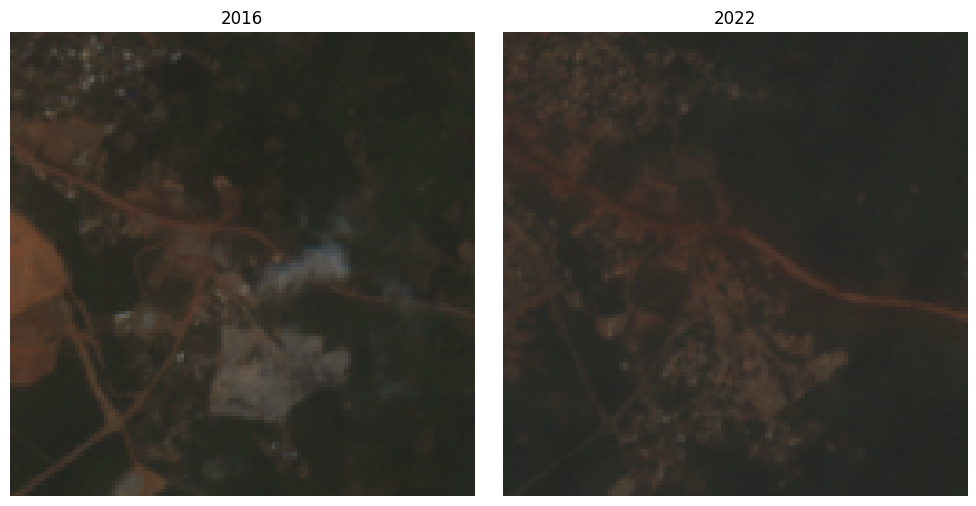

In [9]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

path_2016 = "SmallMinesDS/SmallMinesDS/2016/IMAGE/IMG_GH_0030_2016.tif"
path_2022 = "SmallMinesDS/SmallMinesDS/2022/IMAGE/IMG_GH_0030_2022.tif"

def plot_graph(path, title):
    with rasterio.open(path) as src:
        img = src.read()  # (C, H, W)

    # RGB (bandas 3,2,1) → índices [2,1,0]
    rgb = img[[2, 1, 0]].astype(np.float32)

    # normalización
    rgb = np.clip(rgb, 0, 10000) / 10000.0

    # (C,H,W) → (H,W,C)
    rgb = rgb.transpose(1, 2, 0)

    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")

# 🔥 plot lado a lado
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plot_graph(path_2016, "2016")

plt.subplot(1,2,2)
plot_graph(path_2022, "2022")

plt.tight_layout()
plt.show()

In [12]:
import rasterio
import numpy as np


def inspect_mask_classes(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # leer solo la primera banda

    unique_values, counts = np.unique(mask, return_counts=True)

    print(f"\nArchivo: {mask_path}")
    print(f"Shape: {mask.shape}")
    print(f"Tipo de dato: {mask.dtype}")
    print(f"Valores únicos: {unique_values}")

    print("\nDistribución de clases:")
    total_pixels = mask.size

    for value, count in zip(unique_values, counts):
        percentage = (count / total_pixels) * 100
        print(
            f"Clase {value}: "
            f"{count} píxeles "
            f"({percentage:.4f}%)"
        )


# verificar 2016
path_2016 = "SmallMinesDS/SmallMinesDS/2016/MASK/MASK_GH_0150_2016.tif"
inspect_mask_classes(path_2016)

# verificar 2022
path_2022 = "SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_0150_2022.tif"
inspect_mask_classes(path_2022)

2026-04-23 02:12:03,910 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: C:\Program Files\PostgreSQL\17\share\contrib\postgis-3.5\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-23 02:12:03,910 - WARNING - CPLE_AppDefined in The definition of projected CRS EPSG:32630 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
2026-04-23 02:12:03,912 - WARNING - CPLE_AppDefined in PROJ: proj_create_from_name: C:\Program Files\PostgreSQL\17\share\contrib\postgis-3.5\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-23 02:12:04,001 - WAR


Archivo: SmallMinesDS/SmallMinesDS/2016/MASK/MASK_GH_0150_2016.tif
Shape: (128, 128)
Tipo de dato: uint8
Valores únicos: [0 1]

Distribución de clases:
Clase 0: 15218 píxeles (92.8833%)
Clase 1: 1166 píxeles (7.1167%)

Archivo: SmallMinesDS/SmallMinesDS/2022/MASK/MASK_GH_0150_2022.tif
Shape: (128, 128)
Tipo de dato: uint8
Valores únicos: [0 1]

Distribución de clases:
Clase 0: 12828 píxeles (78.2959%)
Clase 1: 3556 píxeles (21.7041%)
